In [ ]:
import numpy as np # for random numbers and math operations
import matplotlib.pyplot as plt # for 2D plotting

# PyTorch
import torch # main PyTorch library for i.e. multi-dimensional arrays
import torch.nn as nn # imports PyTorch's neural network module which contains layers and model-building components 
                      # i.e. nn.Linear(10,5) meaning 10 input neurons and 5 output neurons and 
                      # i.e. model = nn.Sequential(
                      #                  nn.Linear(10, 5),  # input -> hidden
                      #                  nn.ReLU(),         # or nn.Sigmoid()
                      #                  nn.Linear(5, 1)    # hidden -> output
                      #      )
import torch.optim as optim # Imports optimization algorithms used during training and ppdates model weights to minimize loss
                            # i.e. optim.SGD(model.parameters(), lr=0.01) or optim.Adam(model.parameters(), lr=0.001)

# TensorFlow / Keras
import tensorflow as tf # Imports the main TensorFlow library and provides tensors, automatic differentiation, distributed computing and deep learning tools
from tensorflow import keras
from tensorflow.keras import layers

print("Setup complete")

Setup complete


## Setup

We are testing a drug that was designed to treat an illness. We give the drug to three different groups of people with three different Dosages. Each group consists of 3 people and Group 1 gets the low dosage, group 2 gets the medium dosage and group 3 the high dosage. <br> 
The low and high dosages were not effective so they are set to 0 on the y-axis meaning no efficieny. The medium dosage was effective so it is set to 1 on the y-axis.

## Goal

Fit a curve to the data

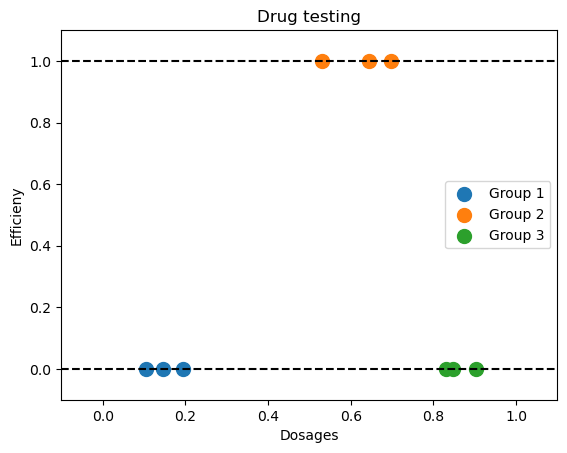

In [77]:
np.random.seed(2228)
group1_dosages = np.random.uniform(0,0.2,3)
group1_efficiency = 3 * [0]
group2_dosages = np.random.uniform(0.25,0.7,3)
group2_efficiency = 3 * [1]
group3_dosages = np.random.uniform(0.75,1,3)
group3_efficiency = 3 * [0]
plt.scatter(group1_dosages,group1_efficiency,s=100,label="Group 1")
plt.scatter(group2_dosages,group2_efficiency,s=100,label="Group 2")
plt.scatter(group3_dosages,group3_efficiency,s=100,label="Group 3")
plt.xlim((-0.1,1.1))
plt.ylim((-0.1,1.1))
plt.xlabel("Dosages")
plt.ylabel("Efficieny")
plt.title("Drug testing")
plt.axhline(1,linestyle="--",c="black")
plt.axhline(0,linestyle="--",c="black")
plt.legend()
plt.show()

## Neural Network

$$
y = W^{(2)} \sigma(W^{(1)}x+b^{(1)})+b^{(3)}
$$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/nn.jpeg" width="550"/>
</div>

- Input: $x \in \mathbb{R}^1$ 
- First weights matrix: $W^{(1)}=\begin{bmatrix} w_{1,1} \\ w_{1,2} \end{bmatrix} \in \mathbb{R}^{2 \times 1}$
- First bias vector: $b^{(1)}=\begin{bmatrix} b_{1} \\ b_{2} \end{bmatrix} \in \mathbb{R}^{2}$

- Second weights matrix: $W^{(2)}=\left[w_{2,1} \quad w_{2,2} \right] \in \mathbb{R}^{1 \times 2}$
- Bias: $b^{(3)} \in \mathbb{R}^1$


### Activation function


<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/Softplus.png" width="550"/>
</div>


### Forward Pass
- $a^{(1)}=W^{(1)}x+b^{(1)}=\begin{bmatrix} w_{1,1}x+b_{1} \\ w_{1,2}x+b_{2} \end{bmatrix} \text{ with } a_{1}^{(1)}=w_{1,1}x+b_{1} \text{ and }a_{2}^{(1)}=w_{1,2}x+b_{2}$

- $z=\sigma(a^{(1)})=\begin{bmatrix} z_{1} \\ z_{2} \end{bmatrix}=\begin{bmatrix} \ln(1+\exp(a_{1}^{(1)})) \\ \ln(1+\exp(a_{2}^{(1)})) \end{bmatrix}$

- $y=W^{(2)}z + b_3=w_{2,1}z_1 + w_{2,2}z_2 + b_3$

- $L=\frac{1}{2}(y-t)^2$


### Backward Pass

$$
\begin{align*}
\frac{\partial L}{\partial b_3}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial b_3}=(y-t)1=y-t \\
\frac{\partial L}{\partial w_{2,1}}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial w_{2,1}}=(y-t)z_1\\
\frac{\partial L}{\partial w_{2,2}}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial w_{2,2}}=(y-t)z_2 \\
\\

\frac{\partial L}{\partial b_1}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial z_1}\frac{\partial z_1}{\partial a_{1}^{(1)}}\frac{\partial a_{1}^{(1)}}{\partial b_1}=(y-t)w_{2,1}\frac{1}{1+\exp(-a_1^{(1)})} \\

\frac{\partial L}{\partial b_2}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial z_2}\frac{\partial z_2}{\partial a_{2}^{(1)}}\frac{\partial a_{2}^{(1)}}{\partial b_2}=(y-t)w_{2,2}\frac{1}{1+\exp(-a_2^{(1)})} \\

\\

\frac{\partial L}{\partial w_{1,1}}&=\frac{\partial L}{\partial y} \frac{\partial y}{\partial z_1}\frac{\partial z_1}{\partial a_{1}^{(1)}}\frac{\partial a_{1}^{(1)}}{\partial w_{1,1}}=(y-t)w_{2,1}\frac{1}{1+\exp(-a_1^{(1)})}x\\

\frac{\partial L}{\partial w_{1,2}}&=\frac{\partial L}{\partial y} \frac{\partial y}{\partial z_2}\frac{\partial z_2}{\partial a_{2}^{(1)}}\frac{\partial a_{2}^{(1)}}{\partial w_{1,2}}=(y-t)w_{2,2}\frac{1}{1+\exp(-a_2^{(1)})}x

\end{align*}
$$

In [78]:
def softplus(x):
    return np.log1p(np.exp(x))


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


class DrugTest:

    def __init__(self, lr=1e-3, epochs=1000, seed=2152):
        np.random.seed(seed)

        # input -> hidden
        self.W1 = np.random.randn(4)
        self.b1 = np.zeros(4)

        # hidden -> output
        self.W2 = np.random.randn(4)
        self.b2 = 0.0

        self.lr = lr
        self.epochs = epochs

    def forward(self, x):
        self.x = x

        self.a1 = self.W1 * x + self.b1
        self.z = softplus(self.a1)

        self.y = self.W2 @ self.z + self.b2

        return self.y

    def backward(self, t):

        # dL/dy
        delta2 = self.y - t

        # output layer gradients
        dW2 = delta2 * self.z
        db2 = delta2 # b_3

        # hidden layer error
        delta1 = delta2* self.W2* sigmoid(self.a1)

        # input layer gradients
        dW1 = delta1 * self.x
        db1 = delta1

        # gradient descent step
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

        return 0.5 * (self.y - t) ** 2

    def train_step(self, x, t):
        y = self.forward(x)
        loss = self.backward(t)
        return y, loss

    def fit(self, X, T):
        losses = []

        for _ in range(self.epochs):
            epoch_loss = 0.0

            for x, t in zip(X, T):
                _, loss = self.train_step(x, t)
                epoch_loss += loss

            losses.append(epoch_loss / len(X))

        return np.array(losses)

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self.forward(x) for x in X])

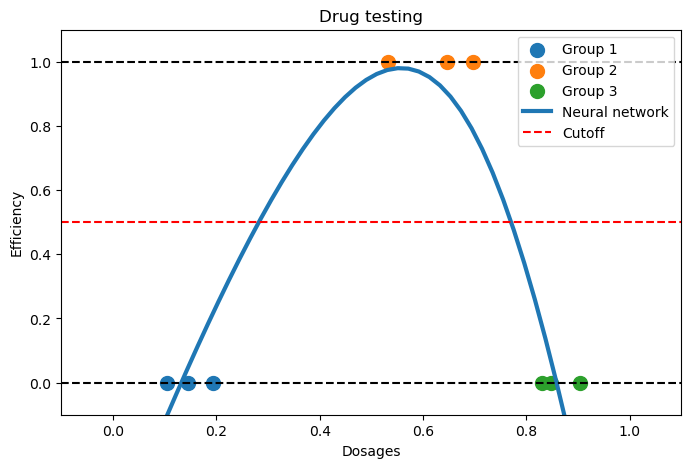

Final loss = 0.018672847437486727
W1 = [-0.71096811 -4.04248125 -0.86538343  8.20857909]
b1 = [-1.55138037  1.96920436 -1.44028066 -5.96909097]
W2 = [ 0.18457195 -1.14870345  0.03348067 -1.20901801]
b2 = 1.863963383775316


In [82]:
X = np.concatenate([group1_dosages,group2_dosages,group3_dosages])
T = np.array(group1_efficiency + group2_efficiency + group3_efficiency)

# Train network
model = DrugTest(lr=0.1,epochs=10000,seed=2227)

losses = model.fit(X, T)


# Evaluate network
x_plot = np.linspace(0, 1, 50)
y_plot = model.predict(x_plot)


# Plot
plt.figure(figsize=(8, 5))

plt.scatter(group1_dosages,group1_efficiency,s=100,label="Group 1")

plt.scatter(group2_dosages,group2_efficiency,s=100,label="Group 2")

plt.scatter(group3_dosages,group3_efficiency,s=100,label="Group 3")

plt.plot(x_plot,y_plot,linewidth=3,label="Neural network")

plt.xlim((-0.1, 1.1))
plt.ylim((-0.1, 1.1))

plt.xlabel("Dosages")
plt.ylabel("Efficiency")
plt.title("Drug testing")

plt.axhline(1, linestyle="--", c="black")
plt.axhline(0, linestyle="--", c="black")
plt.axhline(0.5, linestyle="--", c="red",label="Cutoff")

plt.legend()
plt.show()

print("Final loss =", losses[-1])
print("W1 =", model.W1)
print("b1 =", model.b1)
print("W2 =", model.W2)
print("b2 =", model.b2)